# Load and Prepare Data

This step involves uploading a text file containing a list of names, reading the names from the file, and performing basic data cleaning by stripping whitespace and converting all names to lowercase. Finally, it prints some summary statistics about the loaded names.

### Formulas and Concepts:
- **File Upload**: `files.upload()` is used to prompt the user to select a file from their local system.
- **String Manipulation**: `strip()` removes leading/trailing whitespace, and `lower()` converts strings to lowercase.
- **Basic Statistics**: Calculates the total number of names, the first 10 names, and the shortest, longest, and average length of names.

In [29]:
from google.colab import files
import torch
import torch.nn.functional as F

uploaded = files.upload()

filename = list(uploaded.keys())[0]

with open(filename, "r") as f:
    words = f.read().splitlines()

words = [w.strip().lower() for w in words if w.strip()]

print(f"Total names: {len(words)}")
print(f"First 10 names: {words[:10]}")
print(f"Shortest name: {min(words, key=len)}")
print(f"Longest name:  {max(words, key=len)}")
print(f"Avg length:    {sum(len(w) for w in words) / len(words):.1f} chars")

Saving villains.txt to villains (2).txt
Total names: 285
First 10 names: ['ganondorf', 'bowser', 'sephiroth', 'kefka', 'vaas', 'handsome jack', 'robotnik', 'maleficent', 'illidan', 'arthas']
Shortest name: vaas
Longest name:  eye of the jailer
Avg length:    7.4 chars


# Bigram Counting

This section counts the occurrences of all possible consecutive character pairs (bigrams) across all the names. A special '.' token is added at the beginning and end of each word to capture start and end bigrams (e.g., '.s' for words starting with 's', and 's.' for words ending with 's'). The results are then sorted to show the most common bigrams.

### Formulas and Concepts:
- **Bigram**: A sequence of two adjacent elements from a sequence of tokens. For characters, it's a pair of consecutive characters.
- **Counting**: A dictionary `bigrams` stores each unique bigram as a key and its frequency as the value.
- **Wrapper Token**: The '.' character serves as a start/end-of-word token to model initial and final character probabilities.

In [9]:
bigrams = {}

for w in words:
    chars = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chars, chars[1:]):
        bigram = (ch1, ch2)
        bigrams[bigram] = bigrams.get(bigram, 0) + 1

sorted_bigrams = sorted(bigrams.items(), key=lambda x: x[1], reverse=True)
print("\nTop 20 most common bigrams:")
for (ch1, ch2), count in sorted_bigrams[:20]:
    print(f"  '{ch1}' -> '{ch2}' : {count} times")


Top 20 most common bigrams:
  'n' -> '.' : 62 times
  'a' -> 'r' : 53 times
  's' -> '.' : 50 times
  'e' -> 'r' : 45 times
  'a' -> 'n' : 42 times
  'o' -> 'n' : 41 times
  'r' -> 'a' : 41 times
  'r' -> '.' : 35 times
  't' -> 'h' : 35 times
  'a' -> 'l' : 32 times
  '.' -> 's' : 31 times
  'r' -> 'o' : 28 times
  'r' -> 'i' : 27 times
  'o' -> 'r' : 26 times
  '.' -> 'm' : 25 times
  '.' -> 'a' : 25 times
  'h' -> 'a' : 24 times
  'm' -> 'a' : 23 times
  'u' -> 's' : 22 times
  'r' -> 'e' : 22 times


# Build the Counting Matrix (N)

This step constructs a numerical representation of the bigram counts. It first builds a vocabulary of all unique characters found in the names, including the special '.' token. Then, it creates a `vocab_size x vocab_size` matrix `N` where `N[i, j]` stores the count of how many times the character corresponding to index `j` follows the character corresponding to index `i`.

### Formulas and Concepts:
- **Vocabulary (`chars`)**: A sorted list of all unique characters, starting with '.'.
- **`stoi` (String to Integer)**: A dictionary mapping each character to its numerical index.
- **`itos` (Integer to String)**: A dictionary mapping each numerical index back to its character.
- **Counting Matrix (`N`)**: An adjacency matrix where `N[ix1, ix2]` is incremented for every bigram `(ch1, ch2)`, where `ix1 = stoi[ch1]` and `ix2 = stoi[ch2]`.
- **Shape of N**: `(vocab_size, vocab_size)`.

In [10]:
chars = sorted(set(''.join(words)))
chars = ['.'] + chars

stoi = {s: i for i, s in enumerate(chars)}
itos = {i: s for s, i in stoi.items()}

vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} characters")
print(f"Characters: {''.join(chars)}")

N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

print(f"\nShape of N: {N.shape}")
print(f"\nFirst row of N (what follows '.'):")
for i, count in enumerate(N[0]):
    if count > 0:
        print(f"  '.' -> '{itos[i]}' : {count.item()}")

Vocabulary size: 30 characters
Characters: . '-abcdefghijklmnopqrstuvwxyz

Shape of N: torch.Size([30, 30])

First row of N (what follows '.'):
  '.' -> 'a' : 25
  '.' -> 'b' : 12
  '.' -> 'c' : 12
  '.' -> 'd' : 10
  '.' -> 'e' : 6
  '.' -> 'f' : 7
  '.' -> 'g' : 15
  '.' -> 'h' : 19
  '.' -> 'i' : 7
  '.' -> 'j' : 5
  '.' -> 'k' : 20
  '.' -> 'l' : 9
  '.' -> 'm' : 25
  '.' -> 'n' : 15
  '.' -> 'o' : 6
  '.' -> 'p' : 6
  '.' -> 'q' : 1
  '.' -> 'r' : 21
  '.' -> 's' : 31
  '.' -> 't' : 11
  '.' -> 'u' : 1
  '.' -> 'v' : 14
  '.' -> 'w' : 1
  '.' -> 'y' : 2
  '.' -> 'z' : 4


# Convert Counts to Probabilities (P)

This section converts the raw counts in matrix `N` into probabilities. To prevent zero probabilities for bigrams that were not observed in the training data (which would lead to infinite negative log-likelihood), a smoothing technique is applied by adding 1 to every count (Laplace smoothing). The smoothed counts are then normalized such that each row sums to 1, representing the conditional probability of the next character given the current character.

### Formulas and Concepts:
- **Smoothing**: `P_smoothed = N + 1`. This ensures no probability is zero, allowing for robust log-likelihood calculations.
- **Probability Matrix (`P`)**: Each element `P[i, j]` represents the probability of character `j` following character `i`. It is calculated by dividing each element of the smoothed `N` matrix by the sum of its respective row.
  $$ P[i, j] = \frac{N[i, j] + 1}{\sum_{k=0}^{vocab\_size-1} (N[i, k] + 1)} $$
- **Normalization**: `P = P / P.sum(dim=1, keepdim=True)` ensures that `sum(P[i, :]) == 1.0` for all `i`.

In [30]:
P = (N + 1).float()

P = P / P.sum(dim=1, keepdim=True)

print("Row sums (should all be 1.0):")
print(P.sum(dim=1))

Row sums (should all be 1.0):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000])


# Generate Names from the Counting Model

Using the probability matrix `P`, this step defines a function to generate new names. Starting with the '.' token, it iteratively samples the next character based on the probabilities defined by the current character's row in `P`. This process continues until the '.' token is sampled again, signaling the end of a name. A random seed is set for reproducibility.

### Formulas and Concepts:
- **`torch.Generator().manual_seed()`**: Ensures that random sampling is repeatable.
- **`generate_names(P, itos, stoi, num_names)`**: Function to generate names.
- **Sampling (`torch.multinomial`)**: For a given current character (index `ix`), `torch.multinomial(P[ix], num_samples=1)` samples the next character's index based on the probability distribution in that row of `P`.
- **Name Construction**: Characters are appended until the '.' (index 0) token is sampled, signifying the end of the generated name.

In [31]:
g = torch.Generator().manual_seed(2147483647)

def generate_names(P, itos, stoi, num_names=10):
    names = []

    for _ in range(num_names):
        name = []
        ix = 0

        while True:
            row = P[ix]

            ix = torch.multinomial(row, num_samples=1,
                                   replacement=True,
                                   generator=g).item()

            if ix == 0:
                break

            name.append(itos[ix])

        names.append(''.join(name))

    return names

generated = generate_names(P, itos, stoi, num_names=20)
print("Generated villain names:")
for name in generated:
    print(f"  {name}")

Generated villain names:
  aron
  ruphioilon
  b
  vbeaguepjan
  riumidhtb
  mofel
  rmqfs
  shos ceral
  ndor
  ba
  ktaksm
  kn
  rybalanou
  hbygotircwcgazmonan
  jel
  goreluamaletazvagr'idusonylgn
  db
  kvegepuxn
  gzag'cbynabdbpphalel
  s


# Step 6: Calculate Loss (Negative Log Likelihood) for Counting Model

This step evaluates the quality of the bigram counting model by calculating its negative log-likelihood (NLL). NLL is a common loss function in probabilistic models, measuring how well the model predicts the observed data. A lower NLL indicates a better model. For each bigram in the training data, the model retrieves the probability `P[ch1, ch2]` and calculates its logarithm. These log probabilities are summed up, and then the average negative value is taken.

### Formulas and Concepts:
- **Log Likelihood (LL)**: The sum of the log probabilities of the observed bigrams under the model.
  $$ LL = \sum_{(ch1, ch2) \in \text{dataset}} \log(P(ch2|ch1)) $$
- **Negative Log Likelihood (NLL)**: The negative of the log likelihood. It is commonly used as a loss function because minimizing NLL is equivalent to maximizing LL.
  $$ NLL = -LL $$
- **Average NLL (Loss)**: The total NLL divided by the number of bigrams `n`. This gives an average measure of how well the model predicts each bigram.
  $$ \text{Average NLL} = \frac{-LL}{n} $$

In [32]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob.item()
        n += 1

nll = -log_likelihood
avg_nll = nll / n

print(f"Total bigrams counted : {n}")
print(f"Log likelihood        : {log_likelihood:.4f}")
print(f"Negative log likelihood: {nll:.4f}")
print(f"Average NLL (loss)    : {avg_nll:.4f}")

Total bigrams counted : 2385
Log likelihood        : -6080.9431
Negative log likelihood: 6080.9431
Average NLL (loss)    : 2.5497


# Build the Training Dataset for Neural Network

This step prepares the data for training a neural network model. It iterates through all the names and extracts all bigrams, converting them into numerical pairs: an input `xs` (index of the first character in the bigram) and a target `ys` (index of the second character in the bigram). These are stored as `torch.tensor` objects, forming the training dataset for the neural network.

### Formulas and Concepts:
- **Input (`xs`)**: A tensor containing the integer indices of the first character of each bigram.
- **Target (`ys`)**: A tensor containing the integer indices of the second character of each bigram.
- **Pairing**: For each bigram `(ch1, ch2)`, `xs` will contain `stoi[ch1]` and `ys` will contain `stoi[ch2]`.

In [33]:
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(f"Training examples: {xs.shape[0]}")
print(f"First 5 inputs  : {[itos[i.item()] for i in xs[:5]]}")
print(f"First 5 targets : {[itos[i.item()] for i in ys[:5]]}")

Training examples: 2385
First 5 inputs  : ['.', 'g', 'a', 'n', 'o']
First 5 targets : ['g', 'a', 'n', 'o', 'n']


# Initialize Neural Network Weights

This section initializes the single weight matrix `W` for our simple neural network. In this bigram model, the neural network consists of a single linear layer that takes a one-hot encoded input character and outputs logits for the probability distribution of the next character. The `W` matrix has dimensions `vocab_size x vocab_size`, where each row corresponds to an input character and each column to an output character. It's initialized with random values.

### Formulas and Concepts:
- **Weight Matrix (`W`)**: A `vocab_size x vocab_size` tensor. `W[i, j]` can be interpreted as the 'strength' or 'preference' for character `j` to follow character `i`.
- **Initialization**: `torch.randn()` initializes the weights with random numbers from a standard normal distribution.
- **`requires_grad=True`**: This flag tells PyTorch to track gradients for this tensor, which is essential for backpropagation during training.

In [34]:
g = torch.Generator().manual_seed(2147483647)

W = torch.randn((vocab_size, vocab_size),
                 generator=g,
                 requires_grad=True)

print(f"W shape: {W.shape}")

W shape: torch.Size([30, 30])


# Neural Network Training Loop

This is the core training process for the neural network. The model is trained over a specified number of `STEPS` using gradient descent. In each step, it performs a forward pass to calculate predictions, computes the negative log-likelihood loss, performs a backward pass to calculate gradients, and then updates the weights `W` using a learning rate (`LR`). The loss is printed periodically to monitor training progress.

### Formulas and Concepts:
- **Forward Pass**:
  1. **One-Hot Encoding (`xenc`)**: Converts input character indices `xs` into one-hot vectors. If `xs` is a batch of `N` indices, `xenc` will be an `N x vocab_size` matrix.
     $$ xenc_i = \text{one-hot}(xs_i) $$
  2. **Logits**: The output of the linear layer, obtained by multiplying the one-hot encoded input by the weight matrix `W`.
     $$ logits = xenc \cdot W $$
  3. **Counts (`counts`)**: Exponentiating the logits. This ensures positive values, a prerequisite for probabilities.
     $$ counts = \exp(logits) $$
  4. **Probabilities (`probs`)**: Applying the softmax function to `counts` to get a probability distribution where each row sums to 1.
     $$ probs_{ij} = \frac{\exp(logits_{ij})}{\sum_{k=0}^{vocab\_size-1} \exp(logits_{ik})} $$
- **Loss (Negative Log Likelihood)**:
  The loss is calculated as the average negative log probability of the correct next character (`ys`) given the input character (`xs`).
  $$ \text{Loss} = - \frac{1}{N} \sum_{i=0}^{N-1} \log(probs_{i, ys_i}) $$
- **Backward Pass**: `loss.backward()` computes gradients of the loss with respect to `W`.
- **Weight Update**: `W.data -= LR * W.grad` updates the weights by moving them in the direction opposite to the gradient, scaled by the learning rate `LR`.

In [35]:
STEPS = 200
LR    = 50.0

loss_history = []

for step in range(STEPS):

    xenc = F.one_hot(xs, num_classes=vocab_size).float()

    logits = xenc @ W

    counts = logits.exp()
    probs   = counts / counts.sum(dim=1, keepdim=True)

    correct_probs = probs[torch.arange(xs.shape[0]), ys]
    loss = -correct_probs.log().mean()

    loss_history.append(loss.item())

    W.grad = None
    loss.backward()

    W.data -= LR * W.grad

    if step % 20 == 0 or step == STEPS - 1:
        print(f"step {step:>4} | loss: {loss.item():.4f}")

print(f"\nTarget loss from counting model: 2.5497")

step    0 | loss: 3.9056
step   20 | loss: 2.5872
step   40 | loss: 2.5086
step   60 | loss: 2.4795
step   80 | loss: 2.4641
step  100 | loss: 2.4544
step  120 | loss: 2.4478
step  140 | loss: 2.4429
step  160 | loss: 2.4392
step  180 | loss: 2.4363
step  199 | loss: 2.4341

Target loss from counting model: 2.5497


# Visualize Training Loss

This section plots the training loss (negative log-likelihood) over the course of the neural network's training steps. It also includes a horizontal line representing the loss achieved by the simpler bigram counting model. This visualization helps to understand if the neural network is learning effectively and if it outperforms the baseline counting model.

### Formulas and Concepts:
- **Loss Curve**: A plot showing `Loss (NLL)` on the y-axis against `Step` on the x-axis. A decreasing curve indicates that the model is learning.
- **Counting Model Loss**: A fixed baseline loss (calculated in Step 6) for comparison. The goal is for the neural network's loss to be lower than this baseline, indicating improved performance.

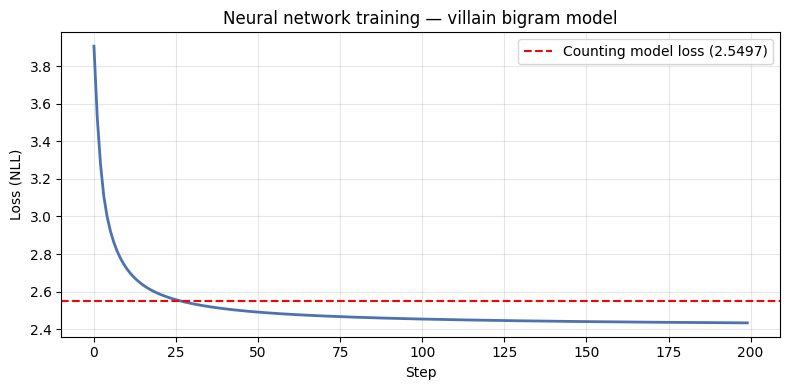

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='#4C72B0', linewidth=2)
plt.axhline(y=2.5497, color='red', linestyle='--',
            linewidth=1.5, label='Counting model loss (2.5497)')
plt.xlabel('Step')
plt.ylabel('Loss (NLL)')
plt.title('Neural network training — villain bigram model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nn_loss.png', dpi=150)
plt.show()

# Generate Names from the Neural Network Model

Similar to the counting model, this step uses the trained neural network to generate new names. Instead of using the `P` matrix directly, it employs the learned weight matrix `W` to compute the probabilities of the next character. The process of sampling and appending characters until an end token is generated remains the same. This allows us to observe the types of names the neural network has learned to produce.

### Formulas and Concepts:
- **`sample_from_nn(W, itos, stoi, num_names)`**: Function to generate names using the neural network's learned weights.
- **Probability Calculation**: For each current character (index `ix`), a one-hot encoded vector `xenc` is created. Logits are calculated as `xenc @ W`, and then softmax is applied (`logits.exp() / logits.exp().sum(dim=1, keepdim=True)`) to obtain the next character probabilities.
- **Sampling**: `torch.multinomial` is used to sample the next character index based on these calculated probabilities.

In [18]:
g2 = torch.Generator().manual_seed(2147483647)

def sample_from_nn(W, itos, stoi, num_names=20):
    names = []
    for _ in range(num_names):
        name = []
        ix = 0
        while True:
            xenc = F.one_hot(torch.tensor([ix]),
                             num_classes=vocab_size).float()
            logits = xenc @ W
            counts = logits.exp()
            probs  = counts / counts.sum(dim=1, keepdim=True)

            ix = torch.multinomial(probs,
                                   num_samples=1,
                                   replacement=True,
                                   generator=g2).item()
            if ix == 0:
                break
            name.append(itos[ix])
        names.append(''.join(name))
    return names

generated_nn = sample_from_nn(W, itos, stoi, num_names=20)
print("Names from neural network:")
for name in generated_nn:
    print(f"  {name}")

Names from neural network:
  aron
  rushioilon
  b
  vanagus
  jan
  riumidrtb
  mofel
  radas
  shos
  ceral
  ndor
  ba
  kanise
  k
  malorianou
  haygothonncgazmonan
  jel
  gorelusmaletaziagr'gonedsylgn
  de
  ke
